# Neural Network Demonstration In Python

## Objective
To develop a model/method for identifying customers who are likely to exit

## Background:
Bank customer churn, also known as customer attrition, refers to the phenomenon where customers stop doing business with a bank or switch to another bank. Churn is a critical metric for banks as it directly impacts their customer base and revenue. The dataset represents bank customer information for churn analysis. Each row in the dataset corresponds to a specific customer and contains several features or attributes that describe them.

While we have worked with Binary Logistic Regression, Naive Bayes, SVM and tree based methods in earlier case study, we will be using neural network in this one.

## Import Libraries


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

## Import Data


In [20]:
data = pd.read_csv('Bank Churn.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Description

Here’s your data in markdown table format:

| Field           | Description                                            |
| --------------- | ------------------------------------------------------ |
| CustomerId      | Customer identifiers                                   |
| Surname         | Surname of Customer                                    |
| CreditScore     | Creditworthiness score of customers                    |
| Geography       | Country name                                           |
| Gender          | Gender of customer                                     |
| Age             | Age of customer                                        |
| Tenure          | Duration of customer engagement or membership          |
| Balance         | Amount of funds held in customer accounts              |
| NumOfProducts   | Number of products or services owned by customers      |
| HasCrCard       | Whether customers possess a credit card or not         |
| IsActiveMember  | Whether customers are active member of loyalty program |
| EstimatedSalary | The approximate salary of customers                    |
| Exited          | Whether customers have churned or exited the service   |


### Splitting Data into Train and Test data sets


In [22]:
X = data.drop(['RowNumber','CustomerId','Exited','Surname'],axis = 1)
y = data['Exited']


# Split data into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Create Dummies and Standardize numeric variables for Train and Test

In [23]:
#Standardize numeric variables
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

# Fit ONLY on training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Use same scaler on test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

#Define categorical columns
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

# Apply get_dummies on TRAIN
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

#Align test columns with train (VERY IMPORTANT)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


# Convert everything to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


## Estimating the attrition rate


In [24]:
counts = data['Exited'].value_counts().reset_index()
counts.columns = ['Exited', 'Freq']
counts['Percent'] = counts['Freq'] / counts['Freq'].sum()

print(counts)

   Exited  Freq  Percent
0       0  7963   0.7963
1       1  2037   0.2037


## Model : Artificial Neural Network

The **MLPClassifier** from scikit-learn is a feedforward artificial neural network used for classification tasks. It supports multiple hidden layers, non-linear activation functions, and learns patterns by minimizing a loss function using backpropagation. It’s suitable for predicting categorical outcomes like customer churn.

In [25]:
classifier = MLPClassifier(hidden_layer_sizes=(3,), max_iter=300,
                           activation = 'relu',solver='adam',random_state=1)
#hidden_layer_sizes=(3,)means → one hidden layer with 3 neurons. 
#For (5,2), it would mean → two hidden layers: the first with 5 neurons, the second with 2 neurons.
#activation = 'relu' -> Activation function introduces non-linearity so the network can learn complex decision boundaries.
#max_iter = the maximum number of training iterations (epochs) the optimizer is allowed to run.
#Adam = Adaptive Moment Estimation ->It’s an optimization algorithm used to update weights in a neural network during training



classifier.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(3,), max_iter=300, random_state=1)

## Generate Classification Report


In [26]:
y_pred_prob = classifier.predict_proba(X_test)[:, 1]

predicted_class = np.zeros(y_pred_prob.shape)
predicted_class[y_pred_prob > 0.3] = 1

# Classification report
print(classification_report(y_test, predicted_class))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.66      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



### ROC Curve and AUC for Test Data

AUC: 0.8574229082703659


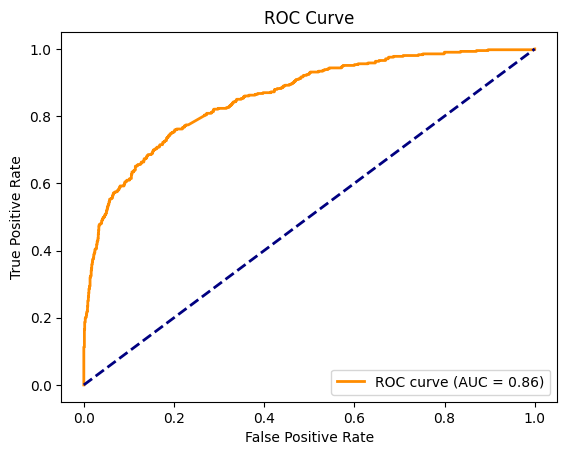

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC:", auc_score)

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


## This is how Neural Network Structure for above model will look like ( For understanding purpose)

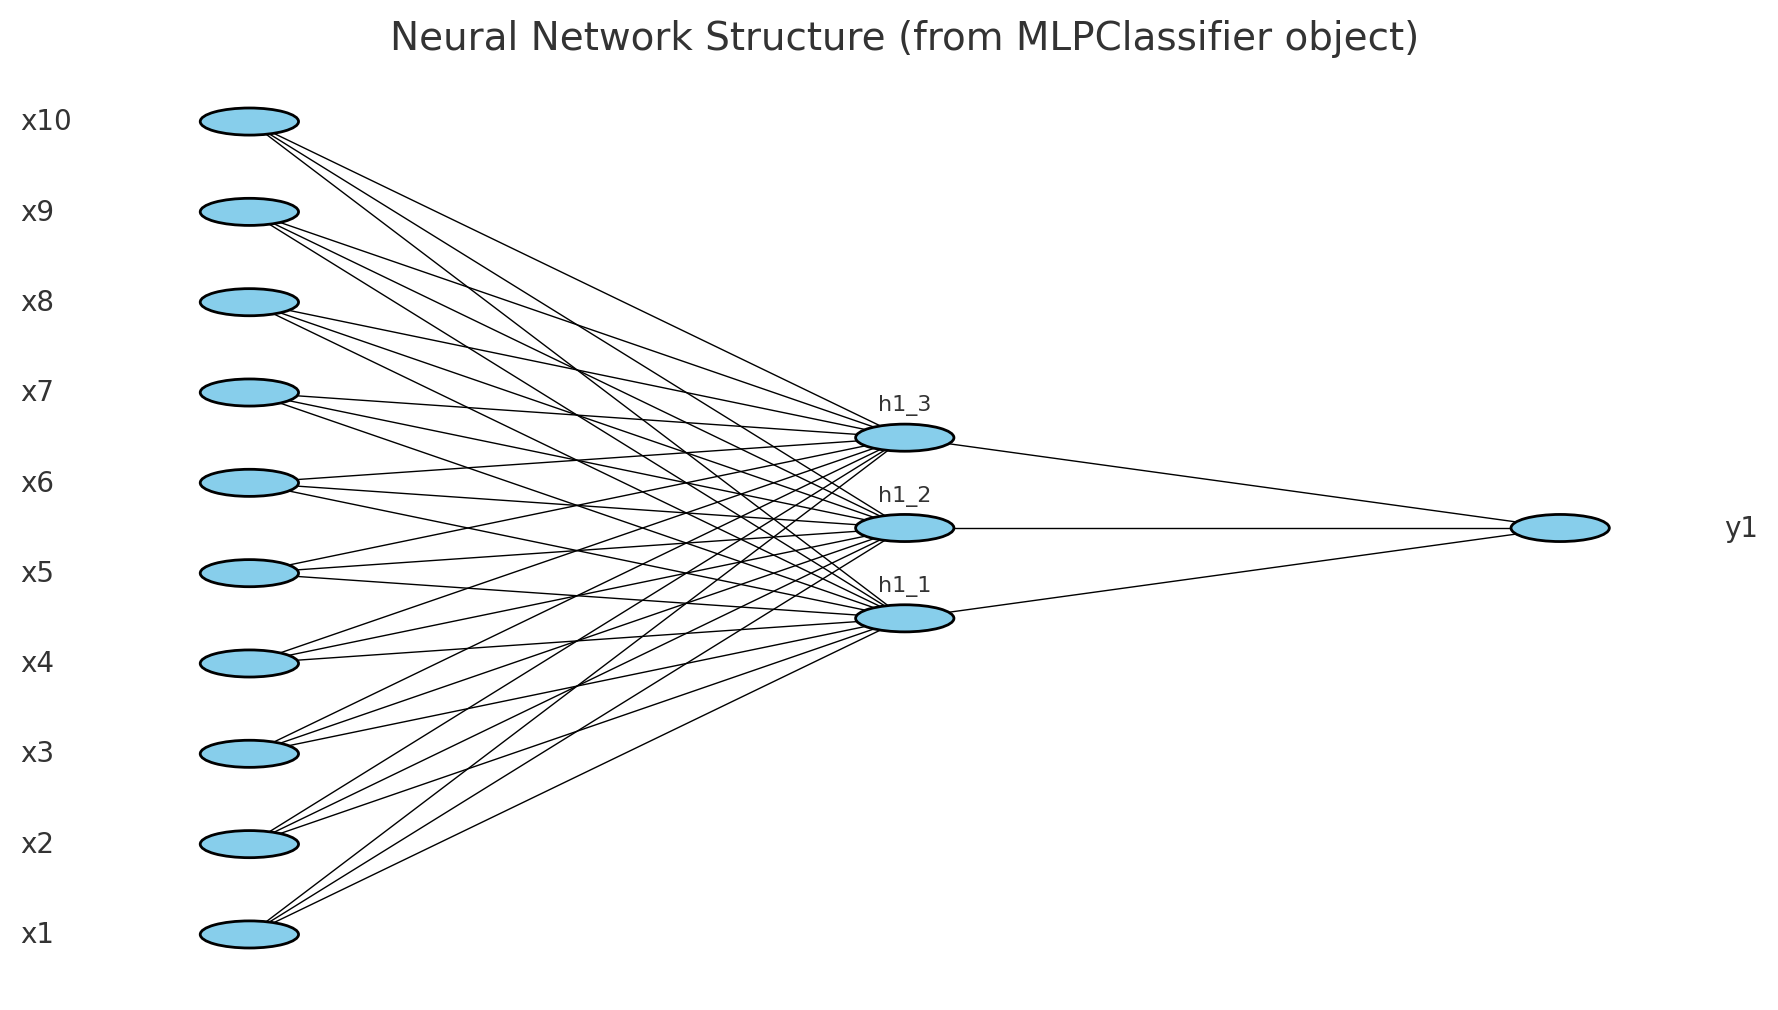